🚍 İctimai Nəqliyyatda Gecikmələrin Analizinə xoş gəlmisiniz 🚆

🌟 Giriş 🌟
Bu layihə ictimai nəqliyyatda baş verən gecikmələrin maraqlı dünyasını araşdırır və şəhər nəqliyyat sistemlərinin dinamikasını əks etdirən zəngin bir dataset üzərində qurulub. Məqsədimiz gecikmələrin arxasında duran nümunələri və əsas səbəbləri aşkar etmək, eyni zamanda nəqliyyat qurumlarına cədvəlləri optimallaşdırmaq və sərnişin təcrübəsini yaxşılaşdırmaqda kömək etməkdir.

🎯 Problemin qoyuluşu 🎯
İctimai nəqliyyatda gecikmələr gündəlik gediş-gəlişə mənfi təsir göstərir, iqtisadi məhsuldarlığı azaldır və sərnişinlərdə narazılıq yaradır. Bu layihədə hava şəraiti, yol sıxlığı və xüsusi tədbirlər kimi faktorları analiz edərək gecikmələrin əsas səbəblərini müəyyənləşdirməyi və Machine Learning (ML) metodlarından istifadə etməklə məlumat əsaslı həllər təklif etməyi hədəfləyirik.

📊 Dataset haqqında məlumat 📊
‘public_transport_delays.csv’ adlı dataset ictimai nəqliyyat səfərləri haqqında detallı məlumatları ehtiva edir və aşağıdakı əsas xüsusiyyətləri özündə birləşdirir:

trip_id: Hər səfər üçün unikal identifikator

date: Səfərin tarixi (məsələn, 2023-01-01)

time: Planlaşdırılmış başlanğıc vaxtı

transport_type: Nəqliyyat növü (Avtobus, Tramvay, Metro, Qatar)

route_id: Marşrut identifikatoru

origin_station & destination_station: Başlanğıc və son dayanacaqlar

scheduled_departure & scheduled_arrival: Planlaşdırılmış çıxış və çatma vaxtları

actual_departure_delay_min & actual_arrival_delay_min: Faktiki gecikmə (dəqiqələrlə)

weather_condition: Hava şəraiti (məsələn, Açıq, Yağışlı, Qarlı)

temperature_C, humidity_percent, wind_speed_kmh, precipitation_mm: Ətraf mühit göstəriciləri

event_type: Xüsusi tədbirlər (məsələn, Konsert, Etiraz, Yoxdur)

event_attendance_est: Təxmini iştirakçı sayı

traffic_congestion_index: Yol sıxlığının göstəricisi

holiday: Bayram günü olub-olmaması (1 və ya 0)

peak_hour: Pik saat olub-olmaması (1 və ya 0)

weekday: Həftənin günü (0–6, burada 0 bazar ertəsidir)

season: Fəsil (Yaz, Yay, Payız, Qış)

delayed: Gecikmə olub-olmaması (1 və ya 0)

🔍 Məqsəd 🔍
Bu datasetdən istifadə edərək müxtəlif nəqliyyat növləri, hava şəraiti və xarici faktorlar (məsələn, tədbirlər və pik saatlar) üzrə gecikmə nümunələrini analiz edəcəyik. Bundan əlavə, Machine Learning modelləri quraraq gecikmələrin baş vermə ehtimalını proqnozlaşdıracağıq. Əldə olunan nəticələr nəqliyyat planlaşdırıcılarına gecikmələri azaltmaq, xidmətin etibarlılığını artırmaq və daha effektiv qərarlar qəbul etməkdə kömək edəcək.

🚀 Gəlin ictimai nəqliyyatı daha səmərəli etmək üçün bu səyahətə başlayaq! 🚀

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/archive (10).zip')

In [ ]:
df.head(5)

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [ ]:
df.shape

(2000, 24)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
trip_id,0
date,0
time,0
transport_type,0
route_id,0
origin_station,0
destination_station,0
scheduled_departure,0
scheduled_arrival,0
actual_departure_delay_min,0


In [ ]:
df['event_type']=df['event_type'].fillna('None')

In [ ]:
df.head(5)

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,None,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,None,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,None,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,None,500,46,0,0,6,Spring,1


In [ ]:
df['actual_departure_delay_min'] = df['actual_departure_delay_min'].apply(lambda x: x if x>0 else 0)

In [ ]:
for col in ['scheduled_departure', 'scheduled_arrival']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')


/tmp/ipykernel_915/3232208030.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_915/3232208030.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [ ]:
df['hour'] = df['scheduled_departure'].dt.hour
df['minute'] = df['scheduled_departure'].dt.minute

In [ ]:
df.head(5)

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,hour,minute
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,2026-03-26 05:02:00,2026-03-26 05:55:00,12,...,None,500,81,0,1,6,Winter,0,5,2
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,2026-03-26 05:16:00,2026-03-26 05:55:00,15,...,None,0,53,0,0,6,Autumn,1,5,16
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,2026-03-26 05:33:00,2026-03-26 06:17:00,0,...,Sports,0,67,1,0,6,Autumn,0,5,33
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,2026-03-26 05:49:00,2026-03-26 06:08:00,15,...,None,500,84,0,0,6,Winter,1,5,49
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,2026-03-26 06:00:00,2026-03-26 06:35:00,0,...,None,500,46,0,0,6,Spring,1,6,0


In [ ]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [ ]:
if 'time' in df.columns:
  df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S', errors='coerce')
  df['hour'] = df['time'].dt.hour
  df['minute'] = df['time'].dt.minute

In [ ]:
df.head(5)

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,hour,minute
0,T00000,2023-01-01,1900-01-01 05:00:00,Tram,Route_15,Station_31,Station_6,2026-03-26 05:02:00,2026-03-26 05:55:00,12,...,None,500,81,0,1,6,Winter,0,5,0
1,T00001,2023-01-01,1900-01-01 05:15:00,Metro,Route_12,Station_49,Station_32,2026-03-26 05:16:00,2026-03-26 05:55:00,15,...,None,0,53,0,0,6,Autumn,1,5,15
2,T00002,2023-01-01,1900-01-01 05:30:00,Bus,Route_16,Station_29,Station_42,2026-03-26 05:33:00,2026-03-26 06:17:00,0,...,Sports,0,67,1,0,6,Autumn,0,5,30
3,T00003,2023-01-01,1900-01-01 05:45:00,Tram,Route_19,Station_26,Station_18,2026-03-26 05:49:00,2026-03-26 06:08:00,15,...,None,500,84,0,0,6,Winter,1,5,45
4,T00004,2023-01-01,1900-01-01 06:00:00,Tram,Route_8,Station_18,Station_15,2026-03-26 06:00:00,2026-03-26 06:35:00,0,...,None,500,46,0,0,6,Spring,1,6,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

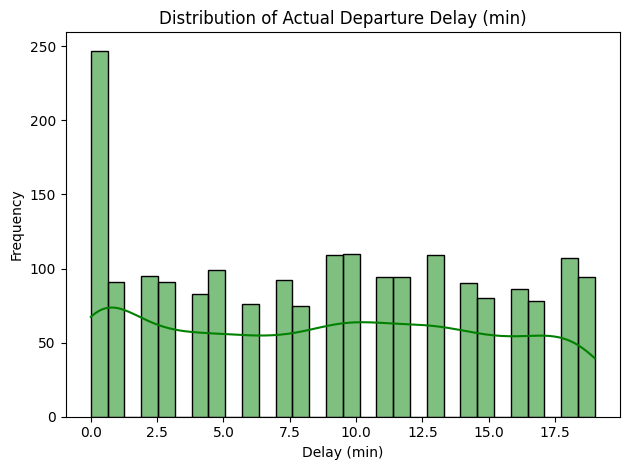

In [ ]:
plt.figure()
sns.histplot(df['actual_departure_delay_min'], kde=True, bins=30, color='green')
plt.title('Distribution of Actual Departure Delay (min)')
plt.xlabel('Delay (min)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

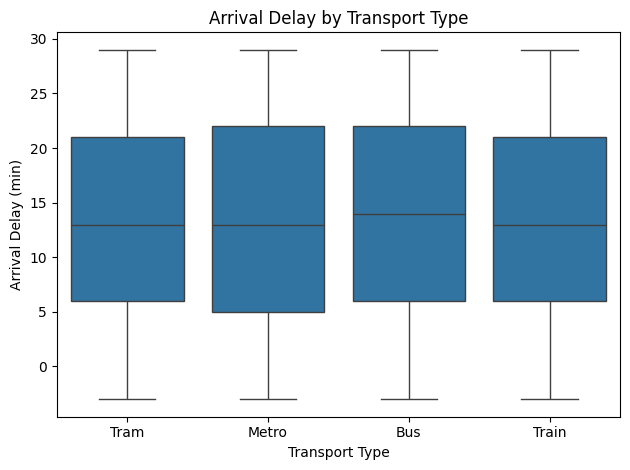

In [ ]:
plt.figure()
sns.boxplot(x='transport_type', y='actual_arrival_delay_min', data=df)
plt.title('Arrival Delay by Transport Type')
plt.xlabel('Transport Type')
plt.ylabel('Arrival Delay (min)')
plt.tight_layout()
plt.show()


/tmp/ipykernel_915/1716891257.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weather_condition', data=df, palette='viridis')


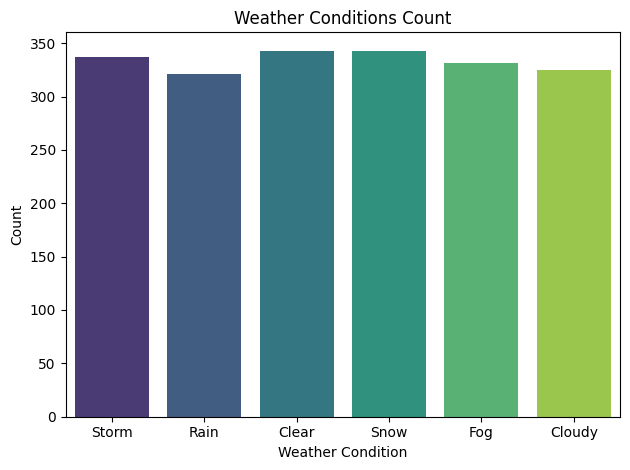

In [ ]:
plt.figure()
sns.countplot(x='weather_condition', data=df, palette='viridis')
plt.title('Weather Conditions Count')
plt.xlabel('Weather Condition')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


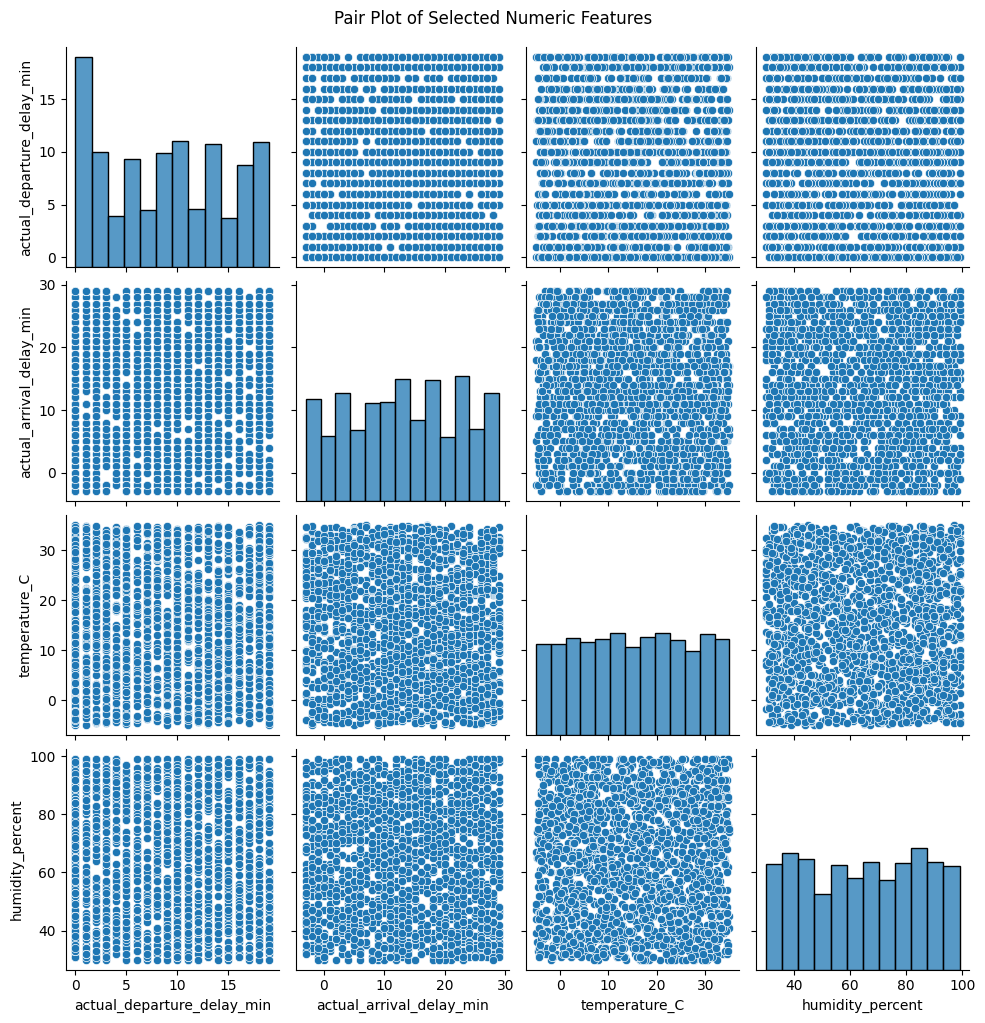

In [ ]:
numeric_columns_to_plot = ['actual_departure_delay_min', 'actual_arrival_delay_min', 'temperature_C', 'humidity_percent']
if all(col in df.columns for col in numeric_columns_to_plot):
    sns.pairplot(df[numeric_columns_to_plot].dropna())
    plt.suptitle('Pair Plot of Selected Numeric Features', y=1.02)
    plt.show()
else:
    print('Not all specified numeric columns are available for pair plot.')


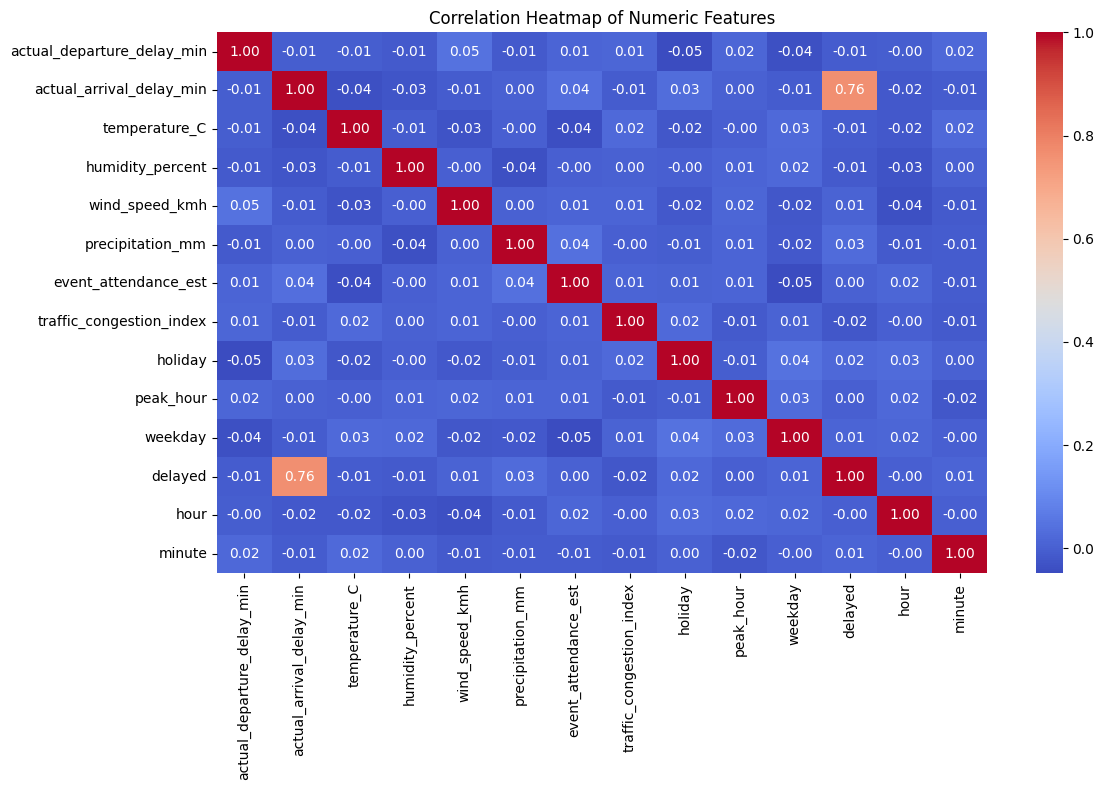

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[LightGBM] [Info] Number of positive: 1049, number of negative: 524
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000570 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 1573, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500238 -> initscore=0.000954
[LightGBM] [Info] Start training from score 0.000954
Ən yaxşı parametrlər: {'model__class_weight': {0: 2, 1: 1}, 'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': -1, 'model__n_estimators': 200, 'model__num_leaves': 31, 'model__subsample': 0.8}
Ən yaxşı threshold: 0.6000000000000001

Confusion Matrix:
[[ 33 117]
 [ 88 362]]

Classification Report:
              precision    recall  f1-score   support

    

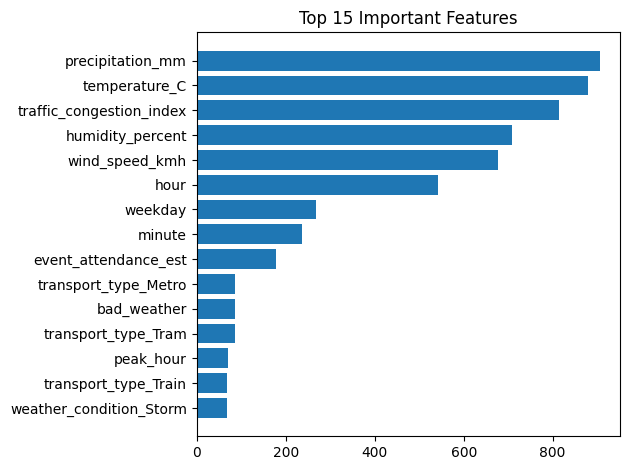

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier

# =========================
# 🔹 FEATURE ENGINEERING
# =========================
df['is_rush_hour'] = df['hour'].isin([7,8,9,17,18,19]).astype(int)

df['bad_weather'] = df['weather_condition'].isin([
    'Rain', 'Storm', 'Snow'
]).astype(int)

df['high_traffic'] = (df['traffic_congestion_index'] > 70).astype(int)

df['weekend'] = df['weekday'].isin([5,6]).astype(int)

# =========================
# 🔹 FEATURE SELECTION
# =========================
features = [
    'temperature_C', 'humidity_percent', 'wind_speed_kmh',
    'precipitation_mm', 'event_attendance_est',
    'traffic_congestion_index', 'holiday', 'peak_hour',
    'weekday', 'transport_type', 'minute', 'hour',
    'weather_condition',
    'is_rush_hour', 'bad_weather', 'high_traffic', 'weekend'
]

# =========================
# 🔹 ENCODING
# =========================
X = pd.get_dummies(df[features],
                   columns=['weather_condition', 'transport_type'],
                   drop_first=True)

y = df['delayed']

# =========================
# 🔹 TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# 🔹 PIPELINE
# =========================
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])

# =========================
# 🔹 HYPERPARAMETER GRID
# =========================
param_grid = {
    'model__n_estimators': [200, 400],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [-1, 10, 20],
    'model__num_leaves': [31, 50],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__class_weight': [{0:2, 1:1}]
}

# =========================
# 🔹 GRID SEARCH
# =========================
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='precision_macro',
    n_jobs=-1,
    verbose=1
)

# =========================
# 🔹 TRAIN
# =========================
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

# =========================
# 🔹 THRESHOLD TUNING (PRECISION üçün)
# =========================
y_probs = best_model.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_precision = 0

for t in np.arange(0.5, 0.9, 0.05):
    y_pred_temp = (y_probs > t).astype(int)
    score = precision_score(y_test, y_pred_temp)

    if score > best_precision:
        best_precision = score
        best_threshold = t

# final prediction
y_pred = (y_probs > best_threshold).astype(int)

# =========================
# 🔹 RESULTS
# =========================
print("Ən yaxşı parametrlər:", grid_search.best_params_)
print("Ən yaxşı threshold:", best_threshold)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================
# 🔹 FEATURE IMPORTANCE
# =========================
importances = best_model.named_steps['model'].feature_importances_
feat_names = X_train.columns

sorted_idx = np.argsort(importances)[-15:]

plt.figure()
plt.barh(range(len(sorted_idx)), importances[sorted_idx])
plt.yticks(range(len(sorted_idx)), feat_names[sorted_idx])
plt.title("Top 15 Important Features")
plt.tight_layout()
plt.show()

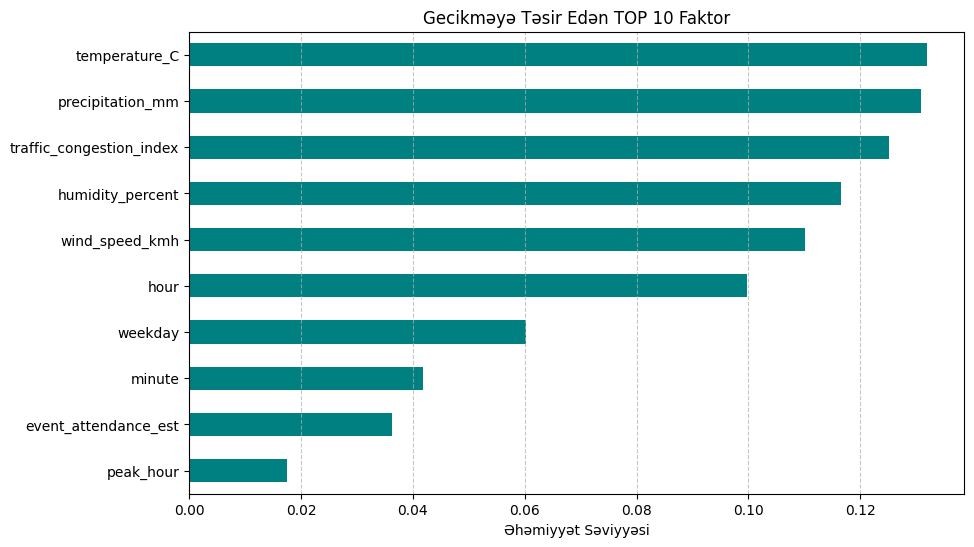

In [ ]:
importances = pd.Series(best_model.feature_importances_, index=x.columns)
top_10_features = importances.nlargest(10).sort_values()
plt.figure(figsize=(10, 6))
top_10_features.plot(kind='barh', color='teal')
plt.title("Gecikməyə Təsir Edən TOP 10 Faktor")
plt.xlabel("Əhəmiyyət Səviyyəsi")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

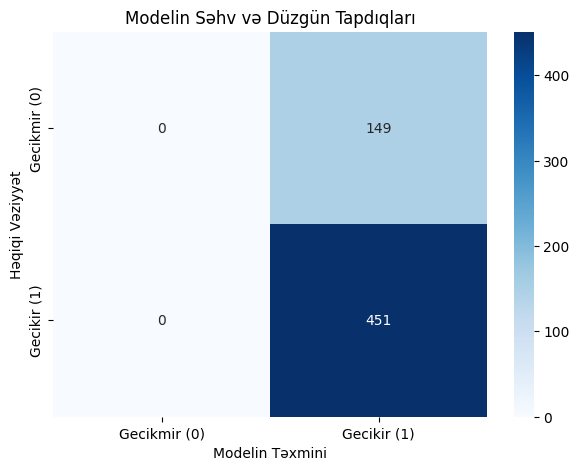

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Gecikmir (0)', 'Gecikir (1)'],
            yticklabels=['Gecikmir (0)', 'Gecikir (1)'])
plt.title('Modelin Səhv və Düzgün Tapdıqları')
plt.xlabel('Modelin Təxmini')
plt.ylabel('Həqiqi Vəziyyət')
plt.show()

In [ ]:
# Test
sample_data = X_test.iloc[0:1]
prediction = best_model.predict(sample_data)
probability = best_model.predict_proba(sample_data)

print(f"Bu vəziyyət üçün proqnoz: {'Gecikəcək' if prediction[0]==1 else 'Gecikməyəcək'}")
print(f"Gecikmə ehtimalı: {probability[0][1]*100:.2f}%")

Bu vəziyyət üçün proqnoz: Gecikəcək
Gecikmə ehtimalı: 84.99%
